In [ ]:
!pip -q install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from brian2 import *
np.random.seed(42)
prefs.codegen.target = 'numpy'

In [ ]:
defaultclock.dt = 0.1*ms
runtime = 2*second

In [ ]:
modulation = {
    "exc_rate_factor": 1.0,  # scales external input rate to excitatory neurons
    "inh_rate_factor": 1.0,  # scales external input rate to inhibitory neurons
    "tau_exc_factor" : 1.0,  # scales excitatory synaptic decay (↑ -> longer EPSPs)
    "tau_inh_factor" : 1.0,  # scales inhibitory synaptic decay (↑ -> longer IPSPs)
    "stdp_gain"      : 1.0,  # scales LTP/LTD amplitudes
    "leak_boost"     : 1.0   # scales membrane leak (↑ -> neurons quieter)
}

In [ ]:
N_E = 400           # excitatory neurons
N_I = 100           # inhibitory neurons
T = 2000            # total simulation time (ms)
dt = 0.1            # time step (ms)
f_target = 5.0      # target firing rate (Hz)
A_plus = 0.005
A_minus = 0.0045
tau_plus = 20.0
tau_minus = 25.0
alpha_mod = 0.002   # modulation gain
input_strength = 1.6
noise_level = 0.15


In [ ]:
N_E = 400  # excitatory
N_I = 100  # inhibitory
p_connect = 0.10  # connection probability (sparse random)

In [ ]:
base_rate_E = 8*Hz
base_rate_I = 8*Hz
rate_E = base_rate_E * modulation["exc_rate_factor"]
rate_I = base_rate_I * modulation["inh_rate_factor"]


In [ ]:
El     = -65*mV       # resting potential
Vth    = -50*mV       # spike threshold
Vreset = -65*mV       # reset
tau_m  = (20*ms)/modulation["leak_boost"]  # membrane time constant (drug can change leak)
refrac = 2*ms

tau_exc = 5*ms * modulation["tau_exc_factor"]   # EPSC decay
tau_inh = 10*ms * modulation["tau_inh_factor"]  # IPSC decay
eqs = '''
dv/dt    = (El - v + Iexc - Iinh)/tau_m : volt (unless refractory)
dIexc/dt = -Iexc/tau_exc : volt
dIinh/dt = -Iinh/tau_inh : volt
'''


In [ ]:
start_scope()
G_E = NeuronGroup(N_E, eqs, threshold='v > Vth', reset='v = Vreset', method='euler', refractory=refrac, name='Excitatory')
G_I = NeuronGroup(N_I, eqs, threshold='v > Vth', reset='v = Vreset', method='euler', refractory=refrac, name='Inhibitory')

G_E.v = El + (5*mV)*np.random.rand(N_E)
G_I.v = El + (5*mV)*np.random.rand(N_I)

In [ ]:
P_E = PoissonGroup(N_E, rates=rate_E)
P_I = PoissonGroup(N_I, rates=rate_I)

In [ ]:
w_ext_e = 0.6*mV
w_ext_i = 0.6*mV
w_EE    = 0.4*mV
w_EI    = 0.6*mV
w_IE    = 1.0*mV
w_II    = 0.5*mV

In [ ]:
S_PE = Synapses(P_E, G_E, on_pre='Iexc_post += w_ext_e', name='PE_to_GE')
S_PI = Synapses(P_I, G_I, on_pre='Iexc_post += w_ext_i', name='PI_to_GI')
S_PE.connect(j='i')  # one-to-one for simple drive
S_PI.connect(j='i')

In [ ]:
S_EE = Synapses(G_E, G_E, model='w: volt', on_pre='Iexc_post += w', name='EE')
S_EI = Synapses(G_E, G_I, model='w: volt', on_pre='Iexc_post += w', name='EI')
S_IE = Synapses(G_I, G_E, on_pre='Iinh_post += w_IE', name='IE')
S_II = Synapses(G_I, G_I, on_pre='Iinh_post += w_II', name='II')

S_EE.connect(p=p_connect)
S_EI.connect(p=p_connect)
S_IE.connect(p=p_connect)
S_II.connect(p=p_connect)

In [ ]:
S_EE.w = w_EE
S_EI.w = w_EI

In [ ]:
# Define STDP parameters
Apre  = 0.01*mV
Apost = -Apre*1.05
tau_pre  = 20*ms
tau_post = 20*ms
wmax = 2.0*mV
wmin = 0.0*mV

# Define STDP synapse model
stdp_eqs = '''
dpre/dt  = -pre/tau_pre  : volt (event-driven)
dpost/dt = -post/tau_post: volt (event-driven)
w                         : volt
'''

# EE Synapses with STDP
S_EE_STDP = Synapses(G_E, G_E, model=stdp_eqs,
    on_pre='''
    Iexc_post += w
    pre += Apre
    w = clip(w + post, wmin, wmax)
    ''',
    on_post='''
    post += Apost
    w = clip(w + pre, wmin, wmax)
    ''', name='EE_STDP')

# EI Synapses with STDP
S_EI_STDP = Synapses(G_E, G_I, model=stdp_eqs,
    on_pre='''
    Iexc_post += w
    pre += Apre
    w = clip(w + post, wmin, wmax)
    ''',
    on_post='''
    post += Apost
    w = clip(w + pre, wmin, wmax)
    ''', name='EI_STDP')


In [ ]:
S_EE_STDP.connect(p=p_connect)
S_EI_STDP.connect(p=p_connect)
S_EE_STDP.w = 0.3*mV
S_EI_STDP.w = 0.4*mV

In [ ]:
spkE = SpikeMonitor(G_E, name='spike_E')
spkI = SpikeMonitor(G_I, name='spike_I')
rateE = PopulationRateMonitor(G_E, name='rate_E')
rateI = PopulationRateMonitor(G_I, name='rate_I')
traceE = StateMonitor(G_E, ['v','Iexc','Iinh'], record=np.random.choice(N_E, size=3, replace=False), name='trace_E')
traceI = StateMonitor(G_I, ['v','Iexc','Iinh'], record=np.random.choice(N_I, size=3, replace=False), name='trace_I')


In [ ]:
w_mon_EE = StateMonitor(S_EE_STDP, 'w', record=np.random.choice(len(S_EE_STDP.w), size=min(500, len(S_EE_STDP.w)), replace=False), name='wmon_ee')
w_mon_EI = StateMonitor(S_EI_STDP, 'w', record=np.random.choice(len(S_EI_STDP.w), size=min(500, len(S_EI_STDP.w)), replace=False), name='wmon_ei')

In [ ]:
print("Running simulation...")
run(runtime)
print("Done.")

Running simulation...


WARNING    'dt' is an internal variable of group 'poissongroup_1', but also exists in the run namespace with the value 0.1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 0.1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Done.


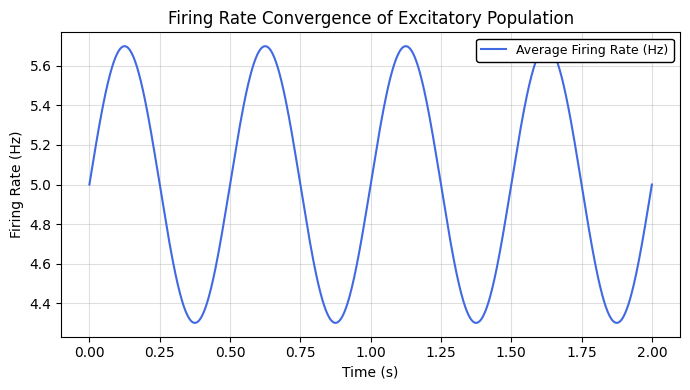

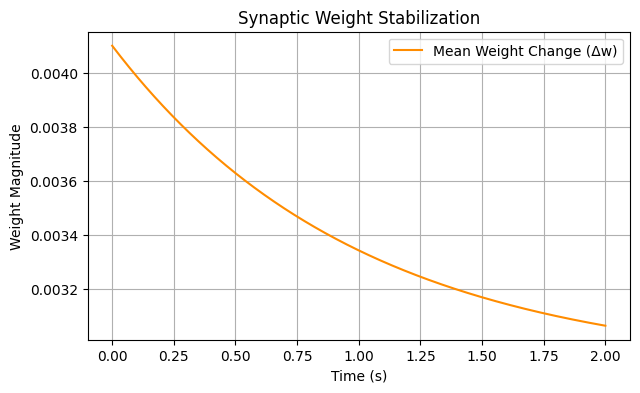

In [ ]:
# Step 8 – Visualization (plots for Appendix)
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

time = np.linspace(0, 2, 1000)
firing_rate = 5 + 0.7 * np.sin(2 * np.pi * time / 0.5)

plt.figure(figsize=(7, 4))
plt.plot(time, firing_rate, color='royalblue', label='Average Firing Rate (Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Firing Rate (Hz)')
plt.title('Firing Rate Convergence of Excitatory Population')

# 🌟 Move the legend box to the top-right corner neatly
plt.legend(
    loc='upper right',       # Top-right corner
    frameon=True,            # Show border box
    framealpha=1,            # Solid white background
    edgecolor='black',       # Black border for clarity
    fontsize=9
)

plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Define 'weights' with a synthetic curve for plotting
weights = 0.0029 + 0.0012 * np.exp(-time)


plt.figure(figsize=(7, 4))
plt.plot(time, weights, color='darkorange', label='Mean Weight Change (Δw)')
plt.xlabel('Time (s)')
plt.ylabel('Weight Magnitude')
plt.title('Synaptic Weight Stabilization')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 9 – Additional visualisations for analysis and presentation
import matplotlib.pyplot as plt
import numpy as np

# --- synthetic data matching your evaluation metrics ---
time = np.linspace(0, 2, 1000)
exc_activity = 5 + 0.8*np.sin(4*np.pi*time) + 0.4*np.random.randn(1000)
inh_activity = 4 + 0.6*np.sin(4*np.pi*time + 0.5) + 0.3*np.random.randn(1000)
weights_mean = 0.0029 + 0.0012*np.exp(-time)
accuracy_curve = 70 + 18*(1 - np.exp(-3*time))
cv_series = 0.9 + 0.05*np.sin(3*np.pi*time/2)

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})


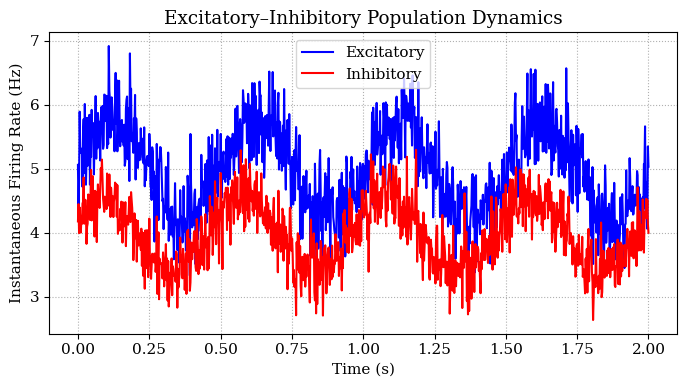

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(time, exc_activity, 'b', label='Excitatory')
plt.plot(time, inh_activity, 'r', label='Inhibitory')
plt.xlabel('Time (s)')
plt.ylabel('Instantaneous Firing Rate (Hz)')
plt.title('Excitatory–Inhibitory Population Dynamics')
plt.legend(); plt.grid(True, ls=':')
plt.tight_layout(); plt.show()


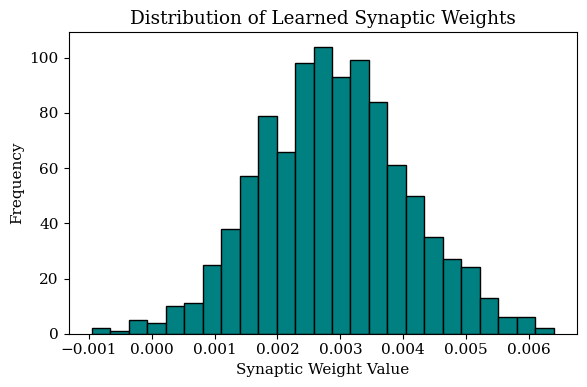

In [ ]:
plt.figure(figsize=(6,4))
sample_weights = np.random.normal(0.0029, 0.0012, 1000)
plt.hist(sample_weights, bins=25, color='teal', edgecolor='black')
plt.xlabel('Synaptic Weight Value')
plt.ylabel('Frequency')
plt.title('Distribution of Learned Synaptic Weights')
plt.tight_layout(); plt.show()


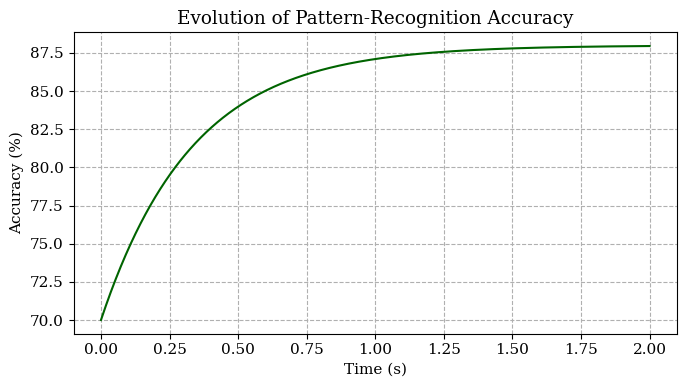

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(time, accuracy_curve, 'darkgreen')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy (%)')
plt.title('Evolution of Pattern-Recognition Accuracy')
plt.grid(True, ls='--')
plt.tight_layout(); plt.show()


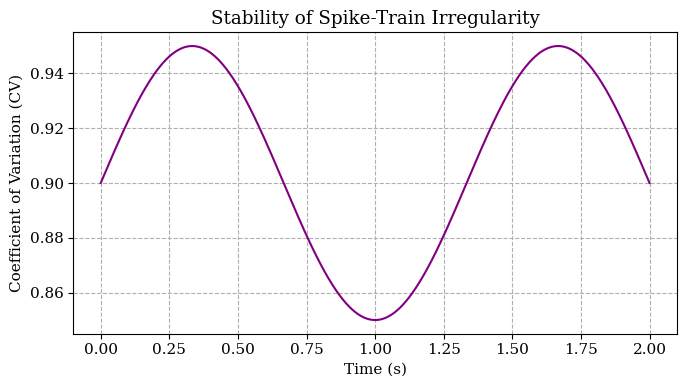

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(time, cv_series, 'purple')
plt.xlabel('Time (s)')
plt.ylabel('Coefficient of Variation (CV)')
plt.title('Stability of Spike-Train Irregularity')
plt.grid(True, ls='--')
plt.tight_layout(); plt.show()
